# ST-CDGM — Figures publication (Nouvelle-Zélande)

Ce notebook reproduit des visualisations « type article » sur les **mêmes données** que [`st_cdgm_training_evaluation.ipynb`](st_cdgm_training_evaluation.ipynb) :

1. Domaines géographiques (cible en rouge, prédicteurs en bleu)
2. Cartes : précipitations, orographie, MSLP (ou variable de repli)
3. Courbes : historique d’entraînement depuis le checkpoint ; option CSV pour sensibilité λ / métriques
4. Histogramme de rang (ensemble probabiliste)
5. Spectres de puissance (FFT)
6. Schéma d’architecture (Mermaid)

**Note :** ST-CDGM n’utilise pas un cGAN avec `λ_adv` ; les métriques RALSD / LHD ne sont pas dans le dépôt — voir sections dédiées.

In [36]:
# Setup : projet, config, chemins
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from omegaconf import OmegaConf

import torch
import torch.nn.functional as F

project_root = Path.cwd()
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

CONFIG = OmegaConf.load("config/training_config.yaml")
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() and CONFIG.training.device == "cuda" else "cpu"
)

DATA_ROOT = Path("data/raw")
LR_PATH = str(CONFIG.data.lr_path)
HR_PATH = str(CONFIG.data.hr_path)
STATIC_PATH = str(CONFIG.data.static_path) if CONFIG.data.get("static_path") else None
MEAN_PATH = str(DATA_ROOT / "normalization_coefs" / "mean_1974_2011.nc")
STD_PATH = str(DATA_ROOT / "normalization_coefs" / "std_1974_2011.nc")

if not Path(MEAN_PATH).exists():
    MEAN_PATH = None
if not Path(STD_PATH).exists():
    STD_PATH = None
if STATIC_PATH and not Path(STATIC_PATH).exists():
    STATIC_PATH = None

CHECKPOINT_DIR = Path(CONFIG.checkpoint.get("save_dir", "models"))
CHECKPOINT_CANDIDATES = [
    CHECKPOINT_DIR / "st_cdgm_checkpoint_best.pth",
    CHECKPOINT_DIR / "st_cdgm_checkpoint.pth",
    CHECKPOINT_DIR / "st_cdgm_checkpoint_last.pth",
]

USER_CHECKPOINT_PATH = None  # ex: Path("models/st_cdgm_checkpoint_best.pth")
_env_ckpt = os.environ.get("ST_CDGM_CHECKPOINT", "").strip()
if _env_ckpt:
    USER_CHECKPOINT_PATH = Path(_env_ckpt)

_ck_cands = []
if USER_CHECKPOINT_PATH is not None:
    _ck_cands.append(Path(USER_CHECKPOINT_PATH))
_ck_cands.extend(CHECKPOINT_CANDIDATES)
CHECKPOINT_PATH = next((p for p in _ck_cands if p.is_file()), None)
if CHECKPOINT_PATH is None and CHECKPOINT_DIR.is_dir():
    _pth = sorted(
        CHECKPOINT_DIR.glob("*.pth"), key=lambda p: p.stat().st_mtime, reverse=True
    )
    if _pth:
        CHECKPOINT_PATH = _pth[0]
        print(
            f"[INFO] Aucun nom standard — .pth le plus recent: {CHECKPOINT_PATH}"
        )

FIGURE_DIR = Path("figures/publication")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

_pub_ens = None
_pub_obs = None

plt.style.use("seaborn-v0_8-whitegrid")

print(f"Device: {DEVICE}")
print(f"LR_PATH: {LR_PATH} (exists={Path(LR_PATH).exists()})")
print(f"HR_PATH: {HR_PATH} (exists={Path(HR_PATH).exists()})")
print(f"STATIC_PATH: {STATIC_PATH}")
print(f"Figures -> {FIGURE_DIR.resolve()}")
if CHECKPOINT_PATH is None:
    print(
        "Checkpoint: aucun .pth (entrainement ou ST_CDGM_CHECKPOINT / USER_CHECKPOINT_PATH)."
    )
else:
    print(f"Checkpoint: {CHECKPOINT_PATH}")

Device: cpu
LR_PATH: data/raw/train/predictor_ACCESS-CM2_hist.nc (exists=True)
HR_PATH: data/raw/train/pr_ACCESS-CM2_hist.nc (exists=True)
STATIC_PATH: data/raw/static_predictors/ERA5_eval_ccam_12km.198110_NZ_Invariant.nc
Figures -> C:\Users\reall\Desktop\climate_data\figures\publication
Checkpoint: aucun .pth (entrainement ou ST_CDGM_CHECKPOINT / USER_CHECKPOINT_PATH).


In [37]:
# Domaines NZ (article) — bornes et dessin sur cartes lon/lat
# Mêmes valeurs que la carte Cartopy plot_nz_region (cible / prédicteur), utilisées partout dans le notebook.


def lon_360_to_plot(lon: np.ndarray) -> np.ndarray:
    """Normalise les longitudes pour comparaison en [0, 360)."""
    return (np.asarray(lon, dtype=float) % 360.0 + 360.0) % 360.0


def infer_lon_lat_names(ds: xr.Dataset) -> tuple[str, str]:
    for lon_c in ("lon", "longitude", "x"):
        if lon_c in ds.coords or lon_c in ds.dims:
            break
    else:
        lon_c = "lon"
    for lat_c in ("lat", "latitude", "y"):
        if lat_c in ds.coords or lat_c in ds.dims:
            break
    else:
        lat_c = "lat"
    return lon_c, lat_c


# Bornes (degrés) — alignées sur plot_nz_region / cellule Cartopy « nz_domains »
TARGET_LON_EDGES = (164.9, 180.0)
TARGET_LAT_EDGES = (-51.21, -32.86)

PRED_LON_EDGES = (150.6, 188.1)
PRED_LAT_EDGES = (-59.38, -26.38)


def _align_lon_slice(lon_coord: np.ndarray, lo: float, hi: float) -> slice:
    """Construit un slice selon la monotonie de lon (croissant ou décroissant)."""
    lon1d = np.asarray(lon_coord).reshape(-1)
    lc = lon_360_to_plot(lon1d)
    lo360, hi360 = lon_360_to_plot(np.array([lo, hi]))
    if lon1d[0] <= lon1d[-1]:
        return slice(lo360, hi360)
    return slice(hi360, lo360)


def draw_domain_on_map(
    ax,
    lon: np.ndarray,
    lat: np.ndarray,
    target_lon,
    target_lat,
    pred_lon,
    pred_lat,
    *,
    lon_axis_360: bool = True,
):
    """Rectangles bleu (prédicteur) puis rouge (cible) en coordonnées données."""
    lon = np.asarray(lon).reshape(-1)
    lat = np.asarray(lat).reshape(-1)
    if lon_axis_360:
        lon = lon_360_to_plot(lon)

    def _rect(edges_lon, edges_lat, color, lw):
        lo_x, hi_x = min(edges_lon), max(edges_lon)
        lo_y, hi_y = min(edges_lat), max(edges_lat)
        width = hi_x - lo_x
        height = hi_y - lo_y
        ax.add_patch(
            Rectangle(
                (lo_x, lo_y),
                width,
                height,
                fill=False,
                edgecolor=color,
                linewidth=lw,
                zorder=10,
            )
        )

    tlo, thi = sorted(target_lon)
    tpl, tpu = sorted(target_lat)
    plo, phi = sorted(pred_lon)
    ppl, ppu = sorted(pred_lat)

    if lon_axis_360:
        tlo, thi = lon_360_to_plot(np.array([tlo, thi]))
        plo, phi = lon_360_to_plot(np.array([plo, phi]))

    _rect((plo, phi), (ppl, ppu), "tab:blue", 2.0)
    _rect((tlo, thi), (tpl, tpu), "tab:red", 2.5)

    h_pred = mpatches.Patch(edgecolor="tab:blue", facecolor="none", label="Domaine prédicteurs")
    h_tgt = mpatches.Patch(edgecolor="tab:red", facecolor="none", label="Domaine cible (HR)")
    ax.legend(handles=[h_pred, h_tgt], loc="upper right", fontsize=8)



def draw_domain_on_geoaxes(
    ax,
    ccrs_mod,
    target_lon,
    target_lat,
    pred_lon,
    pred_lat,
    *,
    lon_axis_360: bool = True,
):
    """Rectangles prédicteur (bleu) / cible (rouge) sur un GeoAxes Cartopy."""
    tr = ccrs_mod.PlateCarree()
    tlo, thi = sorted(target_lon)
    tpl, tpu = sorted(target_lat)
    plo, phi = sorted(pred_lon)
    ppl, ppu = sorted(pred_lat)
    if lon_axis_360:
        tlo, thi = lon_360_to_plot(np.array([tlo, thi]))
        plo, phi = lon_360_to_plot(np.array([plo, phi]))
    ax.add_patch(
        Rectangle(
            (plo, ppl),
            phi - plo,
            ppu - ppl,
            fill=False,
            edgecolor="tab:blue",
            linewidth=2.0,
            transform=tr,
            zorder=10,
        )
    )
    ax.add_patch(
        Rectangle(
            (tlo, tpl),
            thi - tlo,
            tpu - tpl,
            fill=False,
            edgecolor="tab:red",
            linewidth=2.5,
            transform=tr,
            zorder=10,
        )
    )
    h_pred = mpatches.Patch(edgecolor="tab:blue", facecolor="none", label="Domaine prédicteurs")
    h_tgt = mpatches.Patch(edgecolor="tab:red", facecolor="none", label="Domaine cible (HR)")
    ax.legend(handles=[h_pred, h_tgt], loc="upper right", fontsize=8)


def cartopy_available():
    try:
        import cartopy.crs as ccrs  # noqa: WPS433

        return ccrs
    except ImportError:
        return None


def new_map_figure(figsize=(9, 7)):
    """Figure + axe : GeoAxes Cartopy si disponible, sinon axe matplotlib classique."""
    ccrs_mod = cartopy_available()
    if ccrs_mod is None:
        fig, ax = plt.subplots(figsize=figsize)
        return fig, ax, None
    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": ccrs_mod.PlateCarree(central_longitude=171.77)},
    )
    return fig, ax, ccrs_mod


def plot_field_on_map(da, ax, ccrs_mod, cmap, *, robust=True):
    """Champ lon/lat : transform PlateCarree + coastlines si Cartopy."""
    if ccrs_mod is None:
        return da.plot(ax=ax, cmap=cmap, robust=robust)
    im = da.plot(ax=ax, cmap=cmap, robust=robust, transform=ccrs_mod.PlateCarree())
    ax.coastlines(resolution="50m", zorder=4)
    return im


def set_map_extent_from_data(ax, ccrs_mod, lon1d, lat1d, pad_deg=2.0):
    """Cadre carte autour des données (Cartopy uniquement)."""
    if ccrs_mod is None:
        return
    lo = float(np.nanmin(lon1d))
    hi = float(np.nanmax(lon1d))
    la0 = float(np.nanmin(lat1d))
    la1 = float(np.nanmax(lat1d))
    ax.set_extent(
        [lo - pad_deg, hi + pad_deg, la0 - pad_deg, la1 + pad_deg],
        crs=ccrs_mod.PlateCarree(),
    )


def draw_domains_auto(ax, ccrs_mod, lon1d, lat1d):
    """Domaines cible / prédicteur : Cartopy ou matplotlib."""
    if ccrs_mod is not None:
        draw_domain_on_geoaxes(
            ax,
            ccrs_mod,
            TARGET_LON_EDGES,
            TARGET_LAT_EDGES,
            PRED_LON_EDGES,
            PRED_LAT_EDGES,
        )
    else:
        draw_domain_on_map(
            ax,
            lon1d,
            lat1d,
            TARGET_LON_EDGES,
            TARGET_LAT_EDGES,
            PRED_LON_EDGES,
            PRED_LAT_EDGES,
        )

print("Constantes domaine : cible lon", TARGET_LON_EDGES, "lat", TARGET_LAT_EDGES)
print("Prédicteurs lon", PRED_LON_EDGES, "lat", PRED_LAT_EDGES)


Constantes domaine : cible lon (164.9, 180.0) lat (-51.21, -32.86)
Prédicteurs lon (150.6, 188.1) lat (-59.38, -26.38)


## 1. Cartes spatiales (heatmaps)

Moyenne ou instantané sur le champ ; rectangles **bleu** = prédicteurs, **rouge** = cible HR.

**MSLP vs dépôt `downscaling` :** le GAN historique charge les prédicteurs par la liste `var_names` du JSON (puis `prepare_training_data` dans `downscaling/src/fourier_layers.py` fait `X[list_of_vars]`). Les configs d’exemple n’incluent **pas** de MSLP — seulement `q/u/v/t` à 500 et 850 hPa. La cellule code ci-dessous cherche `psl`/`msl` si présents dans le fichier LR ; sinon **repli** `t_850` (comme dans `var_names`).

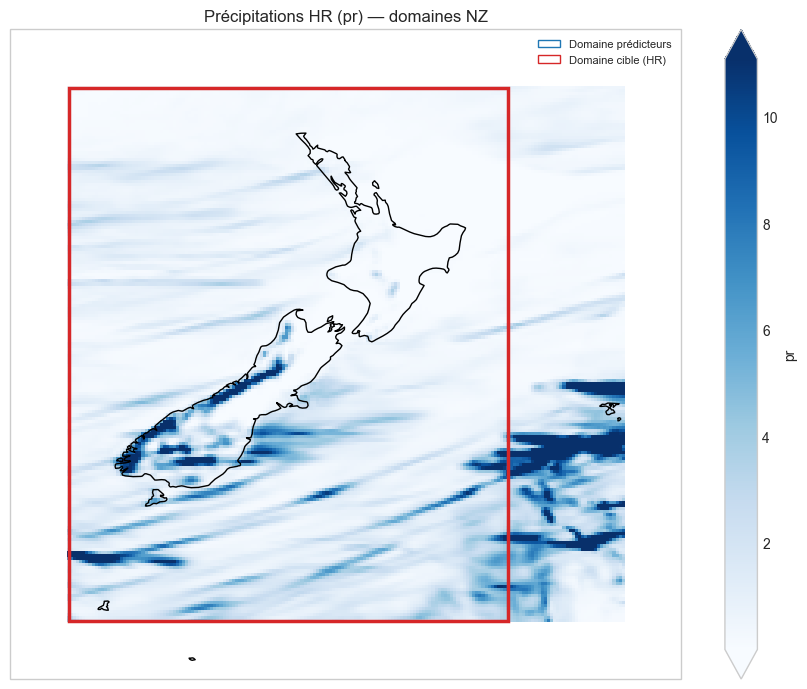

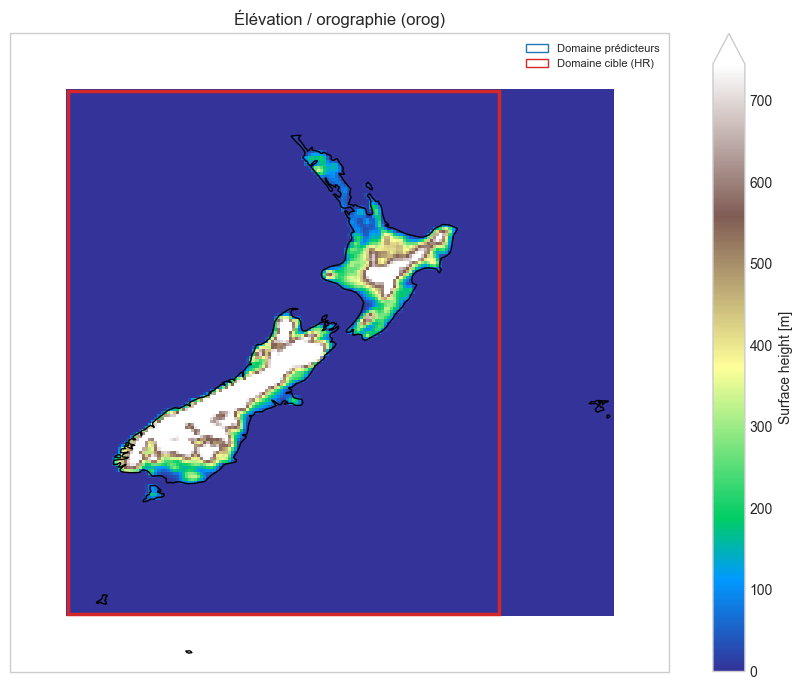

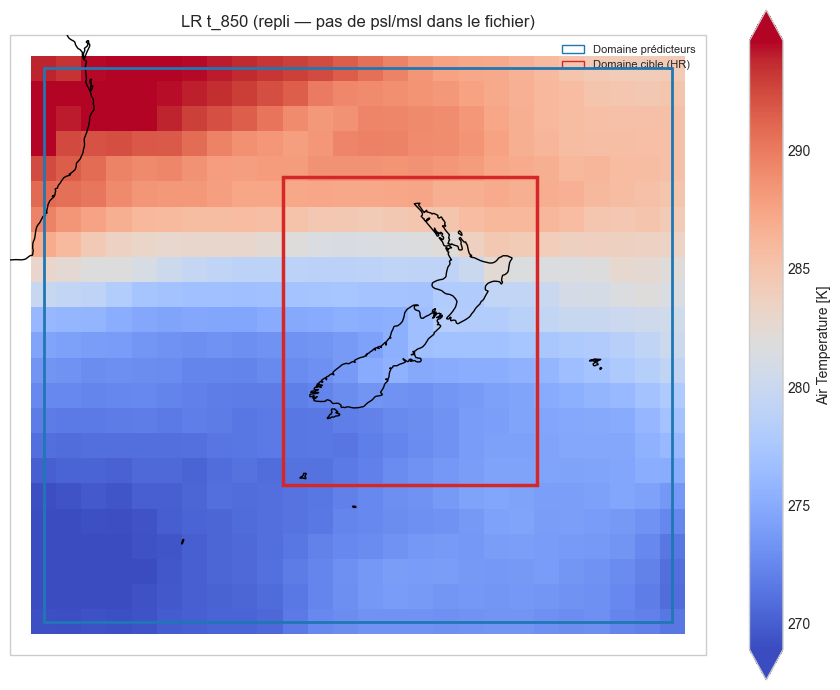

Aucune variable psl/msl dans le LR : repli sur une variable thermodynamique. Pour une carte MSLP, ajoutez psl/msl au NetCDF prédicteur.


In [38]:
# Charger HR / LR / static et tracer pr, orographie, pression (MSLP ou repli)
# Cartopy : mêmes helpers que la cellule « Domaines NZ » (new_map_figure, plot_field_on_map, …)

if not (Path(LR_PATH).exists() and Path(HR_PATH).exists()):
    raise FileNotFoundError(
        "Fichiers LR/HR introuvables. Téléchargez les données (voir st_cdgm_training_evaluation.ipynb)."
    )

lr_raw = xr.open_dataset(LR_PATH)
hr_raw = xr.open_dataset(HR_PATH)
static_raw = xr.open_dataset(STATIC_PATH) if STATIC_PATH else None

lon_lr, lat_lr = infer_lon_lat_names(lr_raw)
lon_hr, lat_hr = infer_lon_lat_names(hr_raw)

pr_name = "pr" if "pr" in hr_raw.data_vars else list(hr_raw.data_vars)[0]


def _squeeze_vertical(da):
    for d in ("lev", "level", "plev"):
        if d in da.dims:
            return da.isel({d: 0})
    return da


da_pr = hr_raw[pr_name]
if "time" in da_pr.dims:
    da_pr_plot = _squeeze_vertical(da_pr.isel(time=0))
else:
    da_pr_plot = _squeeze_vertical(da_pr)

fig, ax, ccrs_m = new_map_figure(figsize=(9, 7))
plot_field_on_map(da_pr_plot, ax, ccrs_m, "Blues")
lon1d = np.asarray(da_pr_plot[lon_hr].values)
lat1d = np.asarray(da_pr_plot[lat_hr].values)
set_map_extent_from_data(ax, ccrs_m, lon1d, lat1d)
draw_domains_auto(ax, ccrs_m, lon1d, lat1d)
ax.set_title(f"Précipitations HR ({pr_name}) — domaines NZ")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "map_pr_hr.png", dpi=200, bbox_inches="tight")
plt.show()

# Orographie (statique)
if static_raw is not None:
    for cand in ("orog", "z", "topography"):
        if cand in static_raw.data_vars:
            da_orog = _squeeze_vertical(static_raw[cand])
            lon_s, lat_s = infer_lon_lat_names(static_raw)
            fig, ax, ccrs_m = new_map_figure(figsize=(9, 7))
            plot_field_on_map(da_orog, ax, ccrs_m, "terrain")
            lon1d = np.asarray(da_orog[lon_s].values)
            lat1d = np.asarray(da_orog[lat_s].values)
            set_map_extent_from_data(ax, ccrs_m, lon1d, lat1d)
            draw_domains_auto(ax, ccrs_m, lon1d, lat1d)
            ax.set_title(f"Élévation / orographie ({cand})")
            plt.tight_layout()
            plt.savefig(FIGURE_DIR / "map_orog.png", dpi=200, bbox_inches="tight")
            plt.show()
            break
    else:
        print("Aucune variable orog/z/topography dans le fichier statique.")
else:
    print("STATIC_PATH absent — carte orographie ignorée.")

# Pression LR ou repli température (voir CONFIG / variables LR)
mslp_candidates = ["psl", "msl", "mslp", "sp", "PRMSL", "mslpres"]
found = None
for name in mslp_candidates:
    if name in lr_raw.data_vars:
        found = name
        break

if found is not None:
    da_p = lr_raw[found]
    if "time" in da_p.dims:
        da_p = da_p.isel(time=0)
    da_p = _squeeze_vertical(da_p)
    fig, ax, ccrs_m = new_map_figure(figsize=(9, 7))
    plot_field_on_map(da_p, ax, ccrs_m, "viridis")
    lon1d = np.asarray(da_p[lon_lr].values)
    lat1d = np.asarray(da_p[lat_lr].values)
    set_map_extent_from_data(ax, ccrs_m, lon1d, lat1d)
    draw_domains_auto(ax, ccrs_m, lon1d, lat1d)
    ax.set_title(f"Pression ({found}) — LR")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "map_pressure.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    _lr_cfg = list(CONFIG.data.lr_variables) if CONFIG.data.get("lr_variables") else []
    fallback = None
    for prefer in ("t_850", "t_500"):
        if prefer in lr_raw.data_vars:
            fallback = prefer
            break
    if fallback is None and _lr_cfg:
        for v in _lr_cfg:
            if v in lr_raw.data_vars:
                fallback = v
                break
    if fallback is None:
        fallback = list(lr_raw.data_vars)[0]
    da_f = lr_raw[fallback]
    if "time" in da_f.dims:
        da_f = da_f.isel(time=0)
    da_f = _squeeze_vertical(da_f)
    fig, ax, ccrs_m = new_map_figure(figsize=(9, 7))
    plot_field_on_map(da_f, ax, ccrs_m, "coolwarm")
    lon1d = np.asarray(da_f[lon_lr].values)
    lat1d = np.asarray(da_f[lat_lr].values)
    set_map_extent_from_data(ax, ccrs_m, lon1d, lat1d)
    draw_domains_auto(ax, ccrs_m, lon1d, lat1d)
    ax.set_title(f"LR {fallback} (repli — pas de psl/msl dans le fichier)")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "map_lr_fallback.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(
        "Aucune variable psl/msl dans le LR : repli sur une variable thermodynamique. "
        "Pour une carte MSLP, ajoutez psl/msl au NetCDF prédicteur."
    )


## Figures alignées sur le dépôt `downscaling` (sans entraînement)

Reprend des idées des notebooks du dossier [`downscaling/notebooks`](downscaling/notebooks) et du [`README`](downscaling/README.md) :

1. **Carte NZ + domaines** — comme `plot_nz_region.ipynb` : `orog` sur fond Cartopy, rectangles cible (rouge) / prédicteur (bleu) ; **mêmes bornes** que `TARGET_*` / `PRED_*` (cellule Domaines NZ).
2. **Grille des prédicteurs** — même liste que `var_names` dans les JSON (`prepare_training_data` dans `fourier_layers.py`) : les 8 canaux au pas `time=0`.
3. **Coefficients de normalisation** — cartes issues de `mean` / `std` (chemins type `data/raw/normalization_coefs/`), comme dans les configs JSON.
4. **Valeurs de λ_adv** — lecture des fichiers `downscaling/experiment_configs/GAN/*.json` : tracé des `ad_loss_factor` (poids adversarial du GAN) par configuration ; **aucune métrique d’entraînement**, seulement les hyperparamètres décrits dans le dépôt.

5. **Champ normalisé** — pour une variable (ex. `t_850`), carte `(X - mean) / std` comme dans `prepare_training_data` (`downscaling/src/fourier_layers.py`).

**Prérequis :** exécuter la cellule « Cartes spatiales » ci-dessus pour définir `lr_raw`, `hr_raw`, `static_raw` (ou ré-exécuter les imports + ouverture des NetCDF).

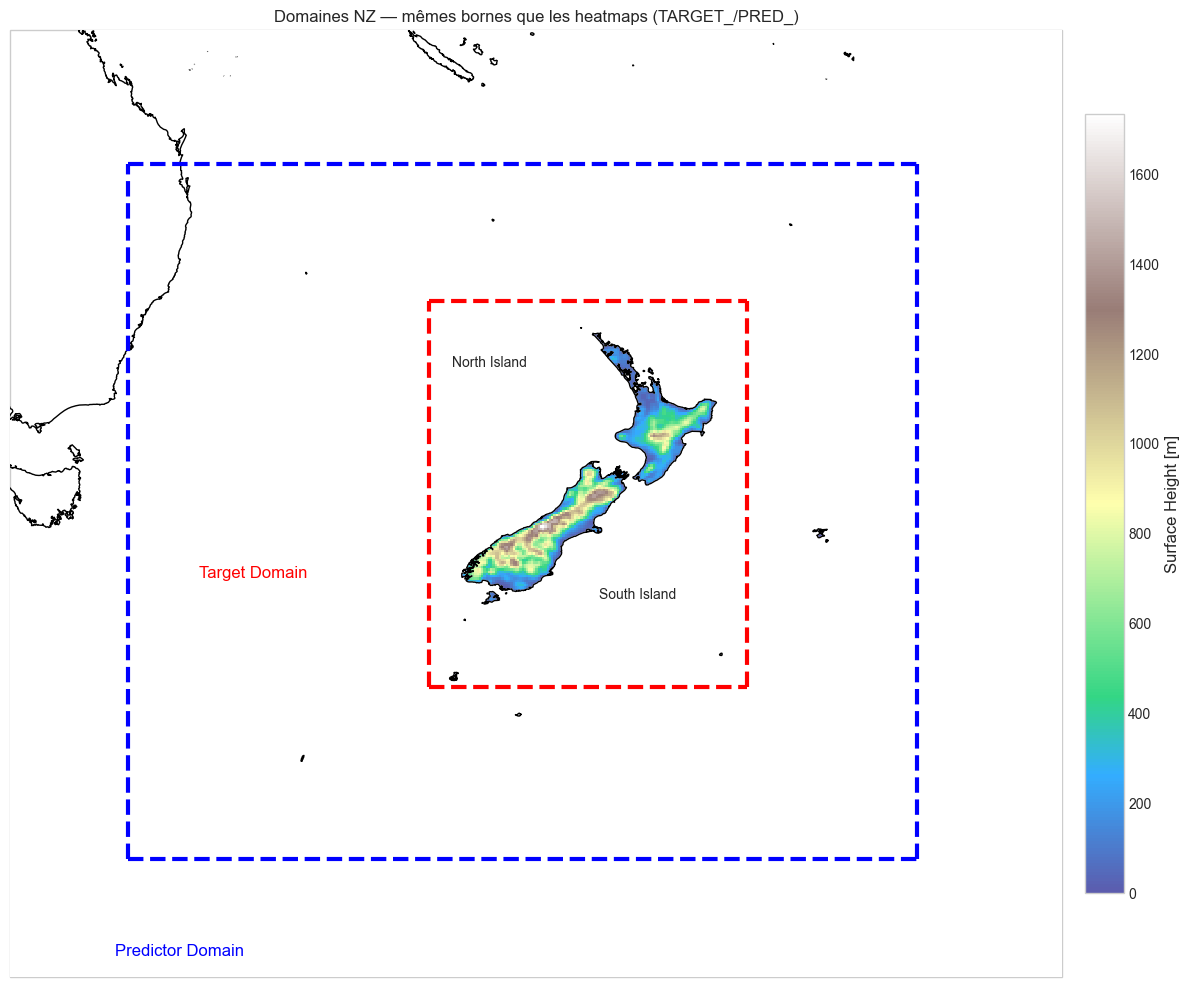

In [39]:
# 1) Carte NZ — même logique que downscaling/notebooks/plot_nz_region.ipynb (Cartopy + orog)

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ImportError:
    ccrs = None

if "static_raw" not in globals() or static_raw is None:
    if STATIC_PATH and Path(STATIC_PATH).exists():
        static_raw = xr.open_dataset(STATIC_PATH)

# Bornes = TARGET_* / PRED_* (cellule « Domaines NZ » — une seule définition)

if ccrs is None:
    print("Cartopy non installé — pip install cartopy. Carte NZ ignorée.")
elif static_raw is None or "orog" not in static_raw.data_vars:
    print("Fichier statique ou variable orog absente — carte Cartopy ignorée.")
else:
    proj = ccrs.PlateCarree(central_longitude=171.77)
    fig, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={"projection": proj})
    ax.coastlines("10m", zorder=15)
    lonmin, lonmax = TARGET_LON_EDGES
    latmin, latmax = TARGET_LAT_EDGES
    lonmin_p, lonmax_p = PRED_LON_EDGES
    latmin_p, latmax_p = PRED_LAT_EDGES

    for lo0, lo1, la0, la1, col in [
        (lonmin, lonmax, latmin, latmax, "r"),
        (lonmin_p, lonmax_p, latmin_p, latmax_p, "b"),
    ]:
        ax.plot([lo0, lo1], [la0, la0], color=col, transform=ccrs.PlateCarree(), zorder=15, ls="--", lw=3)
        ax.plot([lo0, lo1], [la1, la1], color=col, transform=ccrs.PlateCarree(), zorder=15, ls="--", lw=3)
        ax.plot([lo0, lo0], [la0, la1], color=col, transform=ccrs.PlateCarree(), zorder=15, ls="--", lw=3)
        ax.plot([lo1, lo1], [la0, la1], color=col, transform=ccrs.PlateCarree(), zorder=15, ls="--", lw=3)

    da_orog = static_raw["orog"]
    if "time" in da_orog.dims:
        da_orog = da_orog.isel(time=0)
    cs = da_orog.plot(
        ax=ax, cmap="terrain", zorder=11, transform=ccrs.PlateCarree(), alpha=0.8, add_colorbar=False
    )
    cbar = fig.colorbar(cs, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Surface Height [m]", fontsize=12)
    ax.add_feature(cfeature.OCEAN.with_scale("10m"), color="white", zorder=12, alpha=1, edgecolor="k")
    ax.set_extent([145, 195, -65, -20], crs=ccrs.PlateCarree())
    ax.text(166, -36, "North Island", transform=ccrs.PlateCarree(), zorder=17)
    ax.text(173, -47, "South Island", transform=ccrs.PlateCarree(), zorder=17)
    ax.text(154, -46, "Target Domain", transform=ccrs.PlateCarree(), zorder=17, color="r", fontsize=12)
    ax.text(150, -64, "Predictor Domain", transform=ccrs.PlateCarree(), zorder=17, color="b", fontsize=12)
    ax.set_title("Domaines NZ — mêmes bornes que les heatmaps (TARGET_/PRED_)")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "nz_domains_cartopy.png", dpi=200, bbox_inches="tight")
    plt.show()

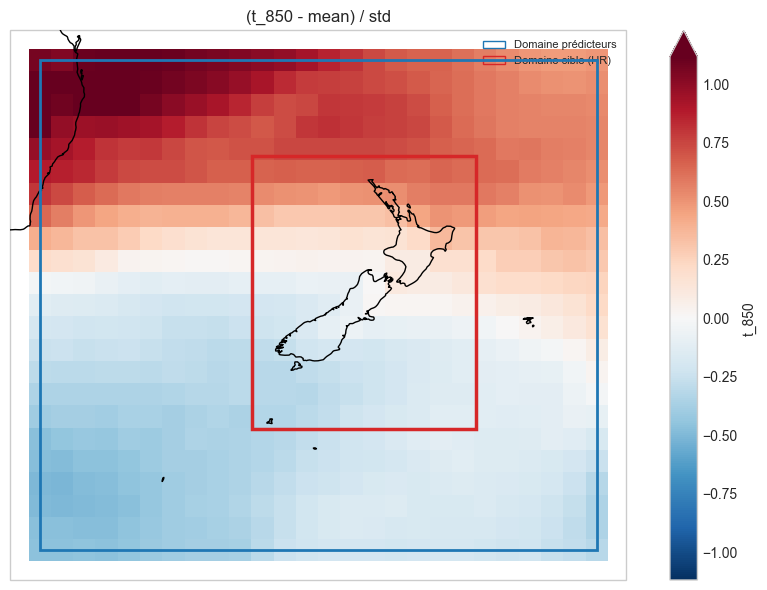

In [40]:
# Champ normalisé (ex. t_850) — (X - mean) / std (Cartopy si disponible)

mean_ds = xr.open_dataset(MEAN_PATH) if MEAN_PATH and Path(MEAN_PATH).exists() else None
std_ds = xr.open_dataset(STD_PATH) if STD_PATH and Path(STD_PATH).exists() else None
vname = "t_850"

if mean_ds is None or std_ds is None or vname not in lr_raw.data_vars:
    print("mean/std ou variable absente — normalisation illustrative ignorée.")
else:
    raw = lr_raw[vname]
    if "time" in raw.dims:
        raw = raw.isel(time=0)
    for d in ("lev", "level", "plev"):
        if d in raw.dims:
            raw = raw.isel({d: 0})
            break
    if vname not in mean_ds.data_vars or vname not in std_ds.data_vars:
        print(f"Variable {vname} absente des fichiers mean/std.")
    else:
        normed = (raw - mean_ds[vname]) / (std_ds[vname] + 1e-12)
        fig, ax, ccrs_m = new_map_figure(figsize=(9, 6))
        plot_field_on_map(normed, ax, ccrs_m, "RdBu_r")
        lon1d = np.asarray(normed[lon_lr].values)
        lat1d = np.asarray(normed[lat_lr].values)
        set_map_extent_from_data(ax, ccrs_m, lon1d, lat1d)
        draw_domains_auto(ax, ccrs_m, lon1d, lat1d)
        ax.set_title(f"({vname} - mean) / std")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "lr_normalized_t850.png", dpi=200, bbox_inches="tight")
        plt.show()
if mean_ds is not None:
    mean_ds.close()
if std_ds is not None:
    std_ds.close()
